<a href="https://colab.research.google.com/github/RedEgnival/sem-4/blob/main/I069_SM_Lab_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rusheel Sharma
# I069
# SM Lab 9
# Multiple Linear Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, classification_report , r2_score

In [ ]:
df = pd.read_csv('/content/Advertising.csv')
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [ ]:
X = df[["TV","radio","newspaper"]]
y = df["sales"]



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

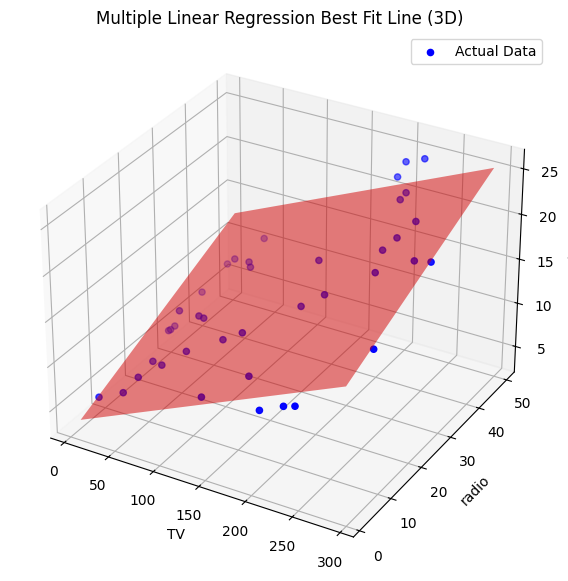

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_test['TV'], X_test['radio'], y_test, color='blue', label='Actual Data')

x1_range = np.linspace(X_test['TV'].min(), X_test['TV'].max(), 100)
x2_range = np.linspace(X_test['radio'].min(), X_test['radio'].max(), 100)

x1, x2 = np.meshgrid(x1_range, x2_range)

# Create a DataFrame with the same columns as X_train for prediction
# We set the 'newspaper' feature to its mean value for simplicity. You might need to adjust this based on your specific use case.
X_pred = pd.DataFrame({'TV': x1.ravel(), 'radio': x2.ravel(), 'newspaper': np.mean(X_test['newspaper'])})

z = model.predict(X_pred).reshape(x1.shape)

ax.plot_surface(x1, x2, z, color='red', alpha=0.5, rstride=100, cstride=100)

ax.set_xlabel('TV')
ax.set_ylabel('radio')
ax.set_zlabel('sales')
ax.set_title('Multiple Linear Regression Best Fit Line (3D)')
plt.legend()
plt.show()

In [ ]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")


Mean Squared Error: 3.1740973539761033
Mean Absolute Error: 1.4607567168117603
R-squared: 0.899438024100912
